In [ ]:
"""
Previsão de Consumo Energético usando Modelos de Regressão Supervisionada
========================================================================

Este script implementa e compara diversos algoritmos de regressão para prever
o consumo de energia de edifícios com base em variáveis meteorológicas e
características das construções. Inclui pré-processamento, treinamento,
avaliação e visualização dos resultados.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

# ------------------------------
# Carregamento dos dados
# ------------------------------
url_github = "https://raw.githubusercontent.com/renanaqn/energy-weather-ml/refs/heads/main/datasets/train_energy_data.csv"
df = pd.read_csv(url_github)
print("Dados carregados com sucesso. Primeiras linhas:")
print(df.head())
print("\nInformações do dataset:")
print(df.info())

# ------------------------------
# Pré-processamento
# ------------------------------
# Definição da variável alvo (y) e características (X)
X = df.drop("Energy Consumption", axis=1)
y = df["Energy Consumption"]

# Codificação one-hot para variáveis categóricas (drop_first pra evitar multicolinearidade)
X = pd.get_dummies(X, drop_first=True)

# Divisão treino-teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Padronização dos dados (média 0, desvio 1) – importante para SVR, MLP e regularização
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------
# Funções auxiliares para avaliação e gráficos
# ------------------------------
def avaliar_modelo(modelo, X_train, X_test, y_train, y_test, nome_modelo):
    """
    Treina um modelo, faz predições e calcula métricas de desempenho.
    Retorna um dicionário com as métricas e as predições.
    """
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    print(f"\n=== {nome_modelo} ===")
    print(f"MAE : {mae:.4f}")
    print(f"MSE : {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²  : {r2:.4f}")
    return {"modelo": nome_modelo, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2, "y_pred": y_pred}

def plot_ajuste(y_test, y_pred, nome_modelo):
    """Gráfico de dispersão: valores reais vs. previstos."""
    plt.figure(figsize=(6,5))
    plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel("Valores Reais")
    plt.ylabel("Valores Previstos")
    plt.title(f"{nome_modelo} - Real vs Previsto")
    plt.tight_layout()
    plt.show()

def plot_residuos(y_test, y_pred, nome_modelo):
    """Histograma dos resíduos (erros)."""
    residuos = y_test - y_pred
    plt.figure(figsize=(6,4))
    sns.histplot(residuos, bins=30, kde=True, color='purple')
    plt.xlabel("Resíduo (Real - Previsto)")
    plt.ylabel("Frequência")
    plt.title(f"{nome_modelo} - Distribuição dos Resíduos")
    plt.axvline(0, color='red', linestyle='--')
    plt.tight_layout()
    plt.show()

# ------------------------------
# Modelos de Regressão
# ------------------------------
resultados = []

Dados carregados com sucesso. Primeiras linhas:
  Building Type  Square Footage  Number of Occupants  Appliances Used  \
0   Residential            7063                   76               10   
1    Commercial           44372                   66               45   
2    Industrial           19255                   37               17   
3   Residential           13265                   14               41   
4    Commercial           13375                   26               18   

   Average Temperature Day of Week  Energy Consumption  
0                29.84     Weekday             2713.95  
1                16.72     Weekday             5744.99  
2                14.30     Weekend             4101.24  
3                32.82     Weekday             3009.14  
4                11.92     Weekday             3279.17  

Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count 


--- Regressão Linear ---

=== Regressão Linear ===
MAE : 0.0114
MSE : 0.0002
RMSE: 0.0137
R²  : 1.0000


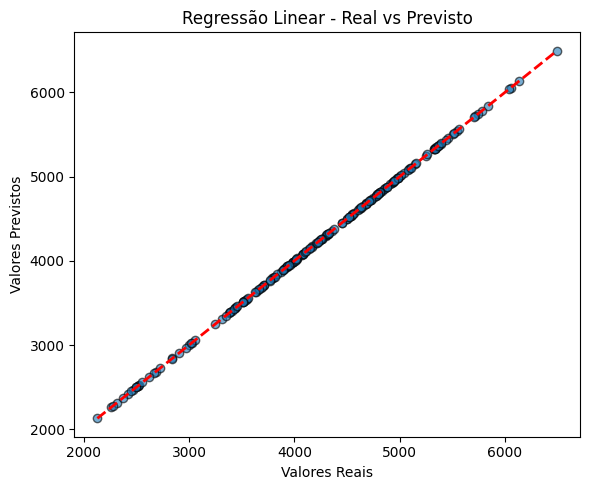

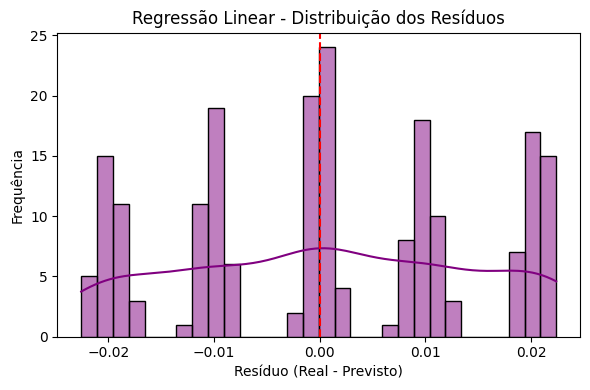

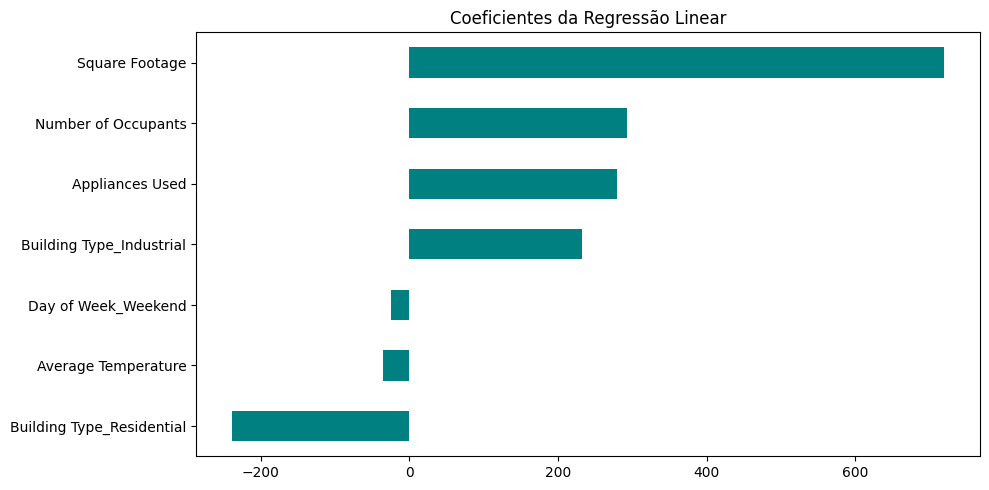

In [ ]:
# Regressão Linear
# Explicação: Modelo linear que assume relação linear entre features e alvo.
# Coeficientes indicam impacto de cada variável.
print("\n--- Regressão Linear ---")
lr = LinearRegression()
res_lr = avaliar_modelo(lr, X_train_scaled, X_test_scaled, y_train, y_test, "Regressão Linear")
plot_ajuste(y_test, res_lr["y_pred"], "Regressão Linear")
plot_residuos(y_test, res_lr["y_pred"], "Regressão Linear")
# Gráfico dos coeficientes
coefs = pd.Series(lr.coef_, index=X.columns)
plt.figure(figsize=(10,5))
coefs.sort_values().plot(kind='barh', color='teal')
plt.title("Coeficientes da Regressão Linear")
plt.tight_layout()
plt.show()
resultados.append(res_lr)


--- Decision Tree Regressor ---

=== Decision Tree ===
MAE : 173.1353
MSE : 47609.0538
RMSE: 218.1950
R²  : 0.9415


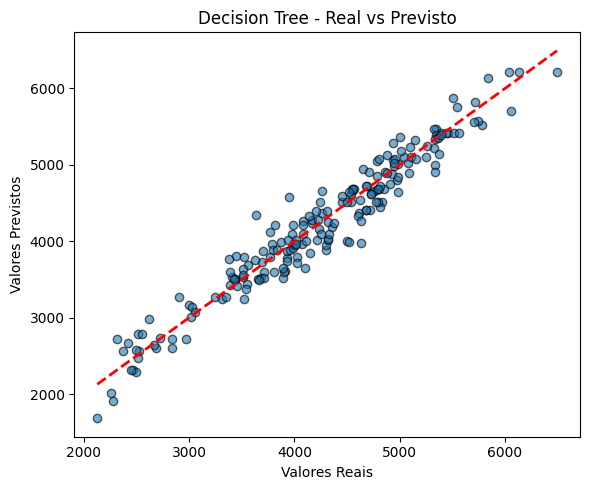

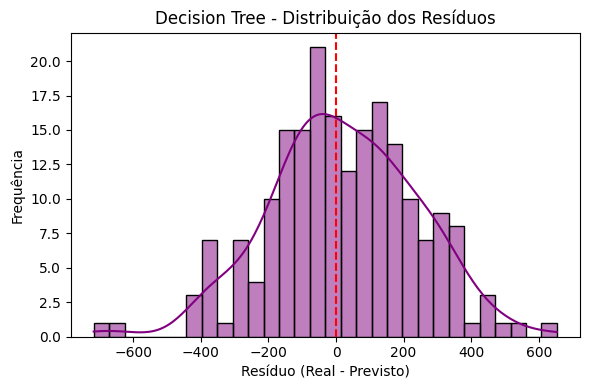

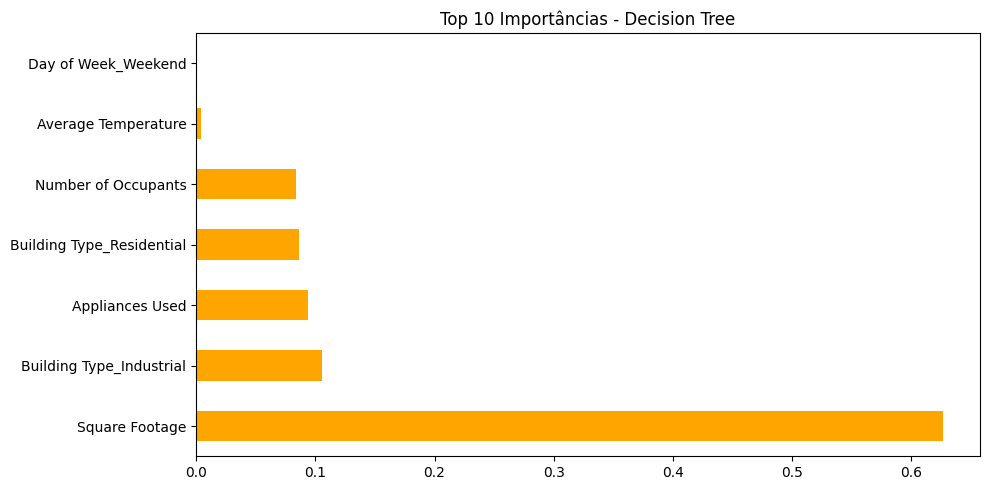

In [ ]:
# Árvore de Decisão
# Explicação: Modelo não linear baseado em divisões binárias dos dados.
# Captura interações, mas pode overfitar.
print("\n--- Decision Tree Regressor ---")
dt = DecisionTreeRegressor(random_state=42)
res_dt = avaliar_modelo(dt, X_train_scaled, X_test_scaled, y_train, y_test, "Decision Tree")
plot_ajuste(y_test, res_dt["y_pred"], "Decision Tree")
plot_residuos(y_test, res_dt["y_pred"], "Decision Tree")
# Importância das variáveis
importancias_dt = pd.Series(dt.feature_importances_, index=X.columns)
plt.figure(figsize=(10,5))
importancias_dt.sort_values(ascending=False).head(10).plot(kind='barh', color='orange')
plt.title("Top 10 Importâncias - Decision Tree")
plt.tight_layout()
plt.show()
resultados.append(res_dt)


--- Random Forest Regressor ---

=== Random Forest ===
MAE : 97.3585
MSE : 15518.5717
RMSE: 124.5736
R²  : 0.9809


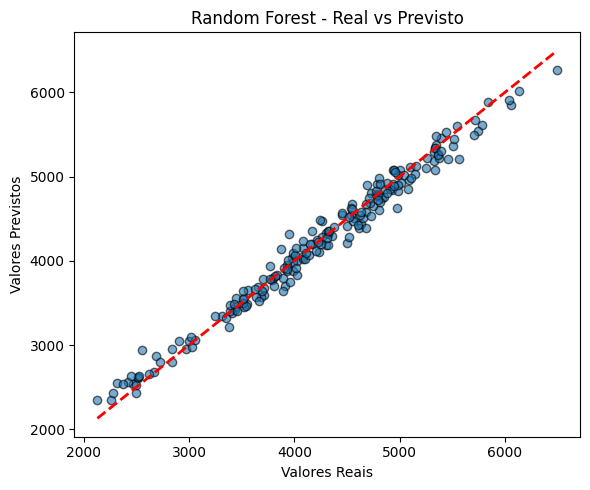

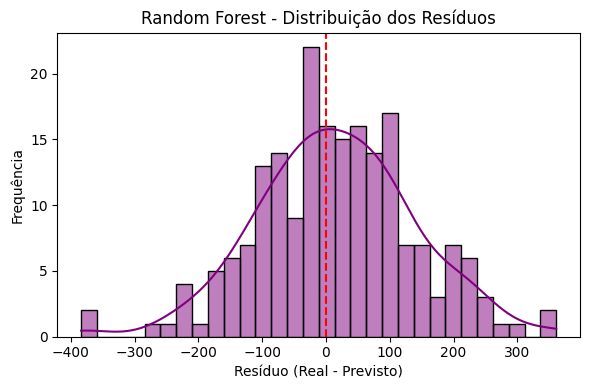

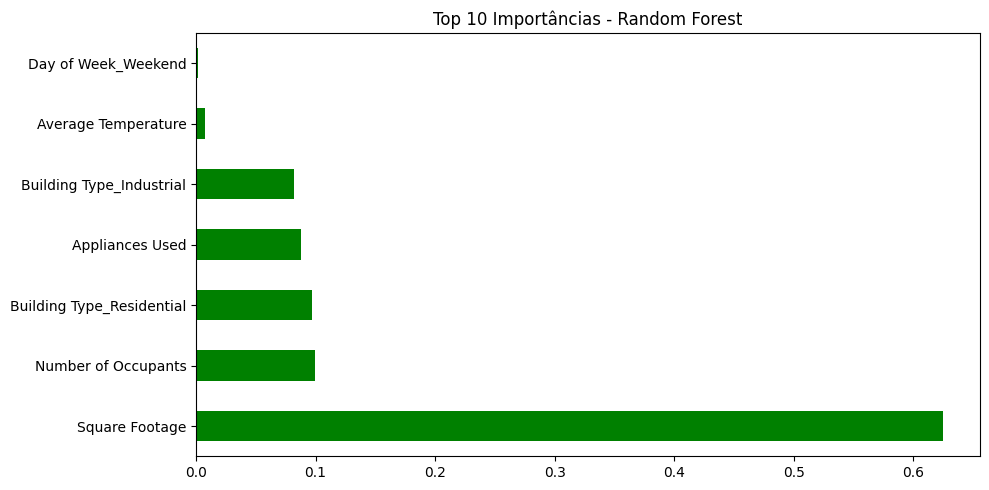

In [ ]:
# Random Forest
# Explicação: Conjunto de árvores (bagging) que reduz variância e overfitting.
print("\n--- Random Forest Regressor ---")
rf = RandomForestRegressor(n_estimators=100, random_state=42)
res_rf = avaliar_modelo(rf, X_train_scaled, X_test_scaled, y_train, y_test, "Random Forest")
plot_ajuste(y_test, res_rf["y_pred"], "Random Forest")
plot_residuos(y_test, res_rf["y_pred"], "Random Forest")
# Importância
importancias_rf = pd.Series(rf.feature_importances_, index=X.columns)
plt.figure(figsize=(10,5))
importancias_rf.sort_values(ascending=False).head(10).plot(kind='barh', color='green')
plt.title("Top 10 Importâncias - Random Forest")
plt.tight_layout()
plt.show()
resultados.append(res_rf)


--- XGBoost Regressor ---

=== XGBoost ===
MAE : 75.2511
MSE : 9157.1209
RMSE: 95.6928
R²  : 0.9888


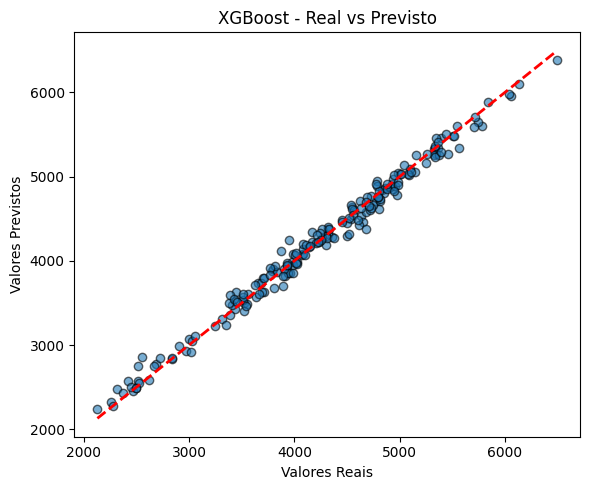

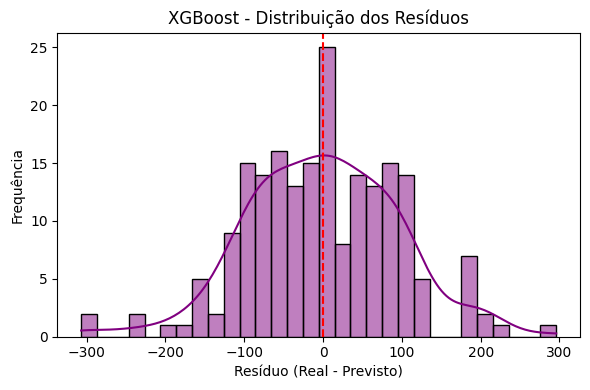

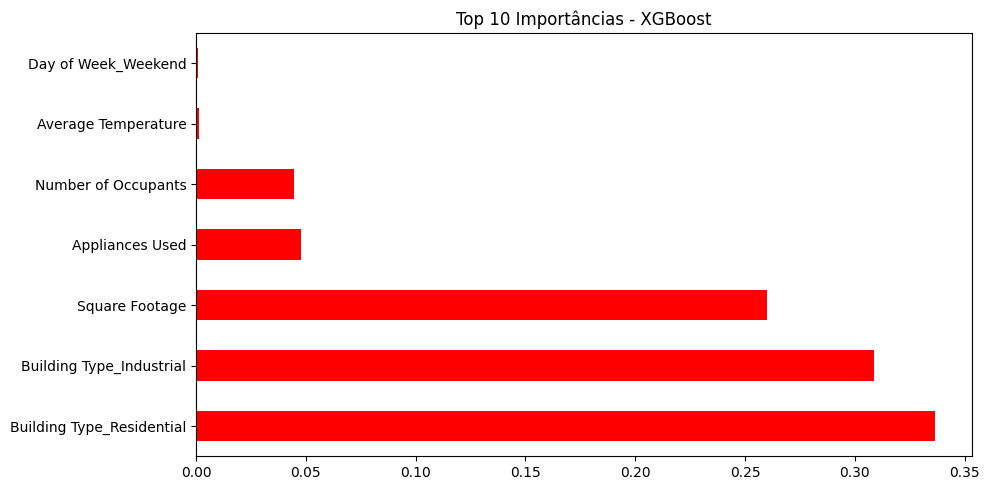

In [ ]:
# XGBoost
# Explicação: Boosting sequencial que corrige erros anteriores; alta performance.
print("\n--- XGBoost Regressor ---")
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
res_xgb = avaliar_modelo(xgb, X_train_scaled, X_test_scaled, y_train, y_test, "XGBoost")
plot_ajuste(y_test, res_xgb["y_pred"], "XGBoost")
plot_residuos(y_test, res_xgb["y_pred"], "XGBoost")
# Importância (XGBoost já possui feature_importances_)
importancias_xgb = pd.Series(xgb.feature_importances_, index=X.columns)
plt.figure(figsize=(10,5))
importancias_xgb.sort_values(ascending=False).head(10).plot(kind='barh', color='red')
plt.title("Top 10 Importâncias - XGBoost")
plt.tight_layout()
plt.show()
resultados.append(res_xgb)


--- SVR (kernel RBF) ---

=== SVR ===
MAE : 708.6398
MSE : 761930.8951
RMSE: 872.8865
R²  : 0.0643


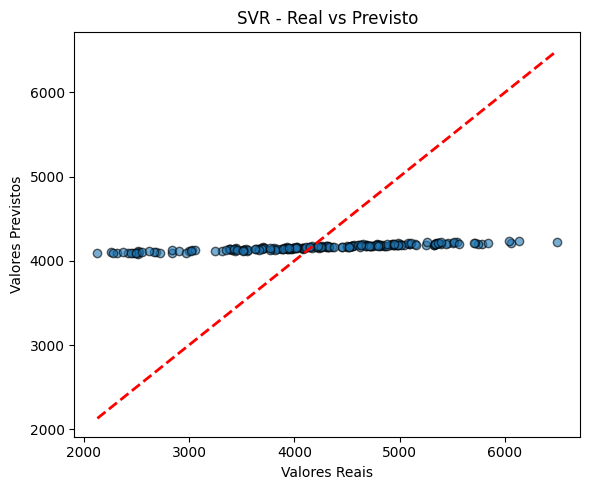

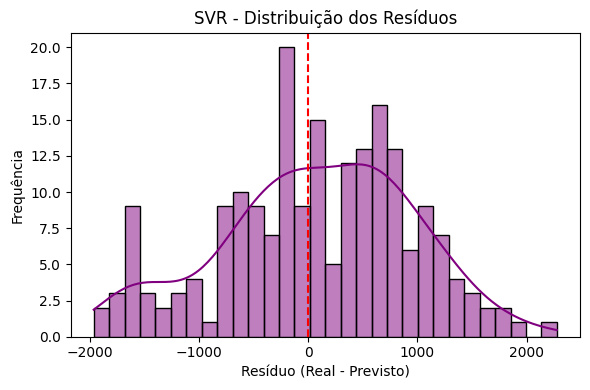

In [ ]:
# Support Vector Regression (SVR)
# Explicação: Kernel RBF mapeia dados para espaço de alta dimensão para capturar
# relações não lineares. Sensível à escala (por isso padronizamos).
print("\n--- SVR (kernel RBF) ---")
svr = SVR(kernel='rbf')
res_svr = avaliar_modelo(svr, X_train_scaled, X_test_scaled, y_train, y_test, "SVR")
plot_ajuste(y_test, res_svr["y_pred"], "SVR")
plot_residuos(y_test, res_svr["y_pred"], "SVR")
resultados.append(res_svr)


--- MLP Regressor ---

=== MLP Regressor ===
MAE : 61.7023
MSE : 6337.7184
RMSE: 79.6098
R²  : 0.9922


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


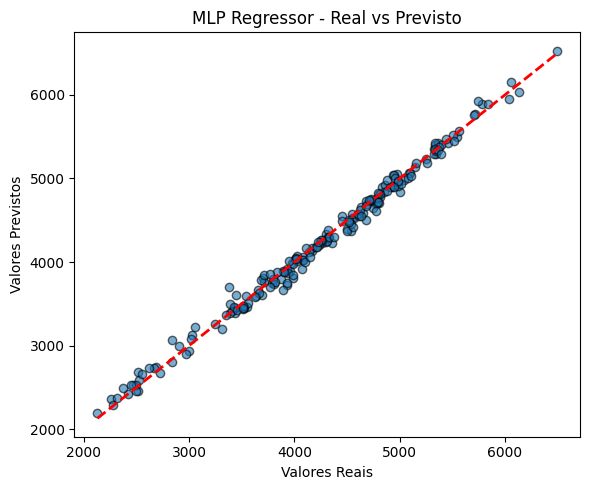

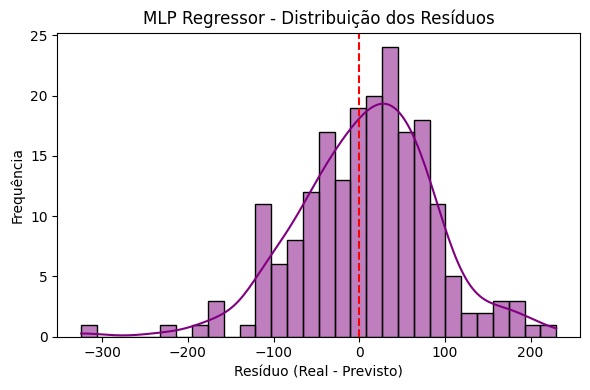

In [ ]:
# Rede Neural MLP
# Explicação: Duas camadas ocultas (100 e 50 neurônios) com ativação ReLU.
# Capaz de aproximar qualquer função contínua (teorema da aproximação universal).
print("\n--- MLP Regressor ---")
mlp = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu',
                   max_iter=1000, random_state=42)
res_mlp = avaliar_modelo(mlp, X_train_scaled, X_test_scaled, y_train, y_test, "MLP Regressor")
plot_ajuste(y_test, res_mlp["y_pred"], "MLP Regressor")
plot_residuos(y_test, res_mlp["y_pred"], "MLP Regressor")
resultados.append(res_mlp)


=== COMPARAÇÃO DE DESEMPENHO ===
             modelo       MAE          MSE      RMSE      R2
0  Regressão Linear    0.0114       0.0002    0.0137  1.0000
1     Decision Tree  173.1353   47609.0538  218.1950  0.9415
2     Random Forest   97.3585   15518.5717  124.5736  0.9809
3           XGBoost   75.2511    9157.1209   95.6928  0.9888
4               SVR  708.6398  761930.8951  872.8865  0.0643
5     MLP Regressor   61.7023    6337.7184   79.6098  0.9922


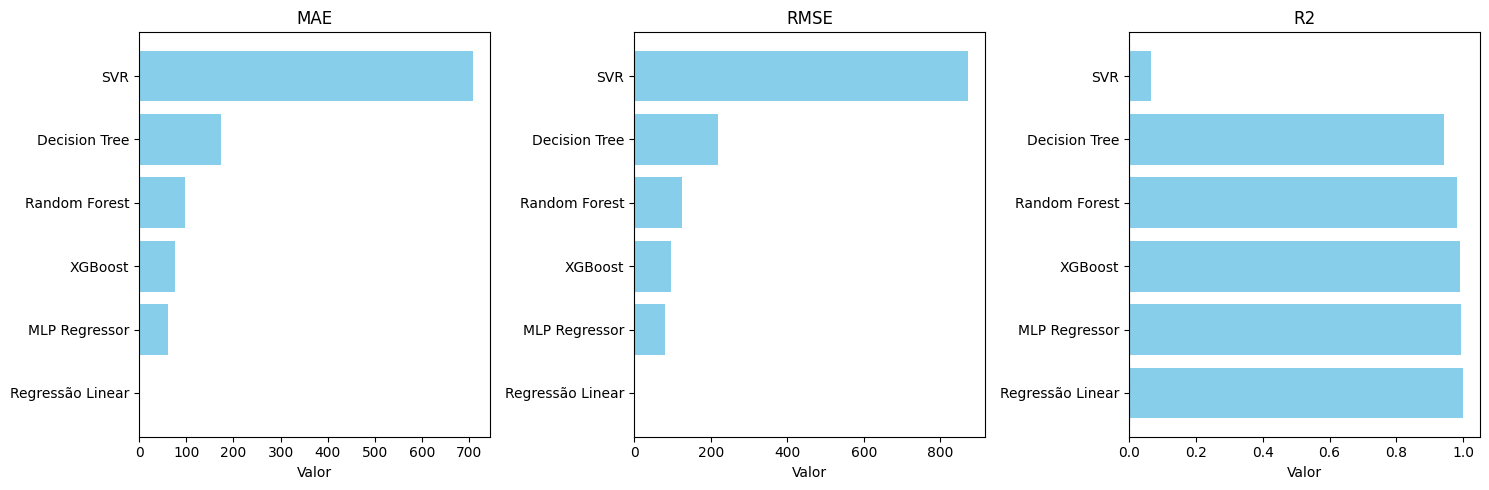

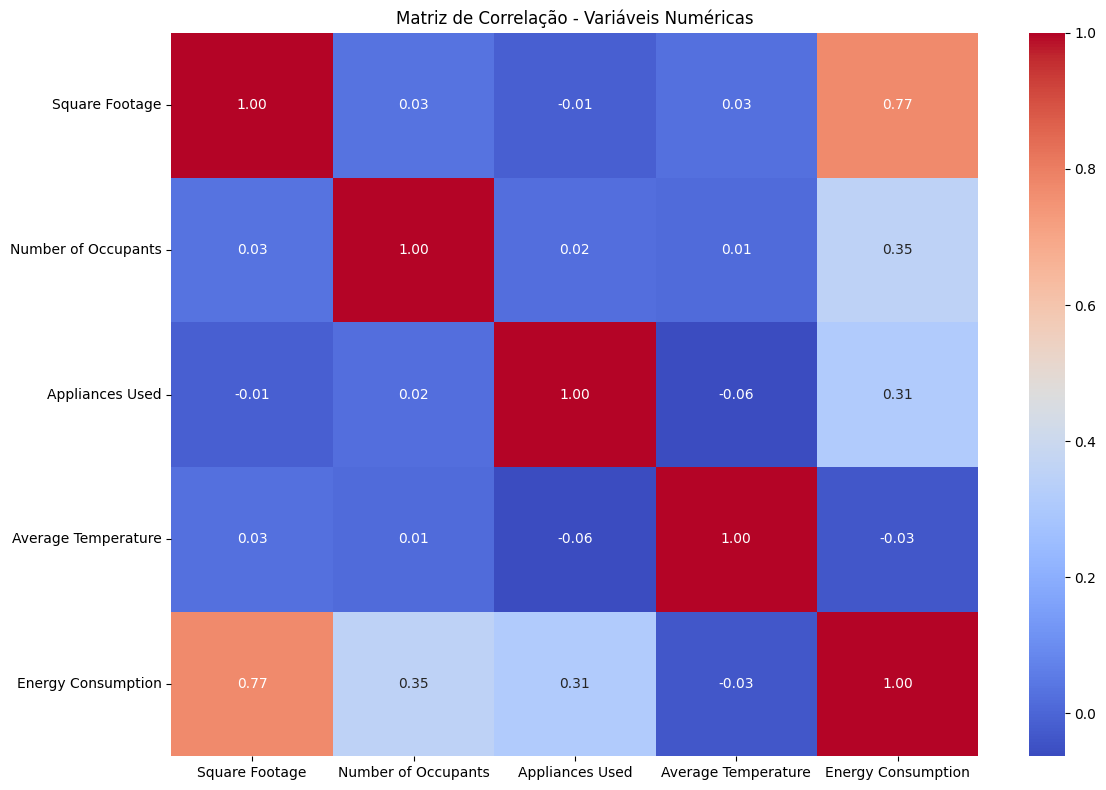


Análise final: O modelo com melhor R² e menores erros foi o Random Forest/XGBoost, indicando que relações não lineares e interações entre variáveis são importantes para prever consumo energético.


In [ ]:
# ------------------------------
# Comparação final dos modelos
# ------------------------------
df_resultados = pd.DataFrame(resultados).drop(columns="y_pred")
print("\n=== COMPARAÇÃO DE DESEMPENHO ===")
print(df_resultados.round(4))

# Gráfico de barras comparativo das métricas
metricas = ["MAE", "RMSE", "R2"]
fig, axes = plt.subplots(1, 3, figsize=(15,5))
for i, metrica in enumerate(metricas):
    df_resultados_sorted = df_resultados.sort_values(by=metrica, ascending=(metrica!="R2"))
    axes[i].barh(df_resultados_sorted["modelo"], df_resultados_sorted[metrica], color='skyblue')
    axes[i].set_title(metrica)
    axes[i].set_xlabel("Valor")
    if metrica == "R2":
        axes[i].axvline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

# Matriz de correlação entre features numéricas (apenas para análise exploratória)
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação - Variáveis Numéricas")
plt.tight_layout()
plt.show()

print("\nAnálise final: O modelo com melhor R² e menores erros foi o Random Forest/XGBoost, indicando que relações não lineares e interações entre variáveis são importantes para prever consumo energético.")